STEP 1: Load Data (SMOTE Version)

In [7]:
import pandas as pd

X_train_resampled = pd.read_csv("X_train_resampled.csv")
y_train_resampled = pd.read_csv("y_train_resampled.csv")

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

y_train_resampled = y_train_resampled.values.ravel()
y_test = y_test.values.ravel()

STEP 2: Train Logistic Regression (SMOTE)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


STEP 3: Predictions (SMOTE)

In [9]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

STEP 4: Evaluation (SMOTE)

In [10]:
print("=== SMOTE Default Threshold ===")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== SMOTE Default Threshold ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.970028112187475


STEP 5: Threshold Tuning (SMOTE)

In [11]:
threshold = 0.9
y_pred_new = (y_prob_lr >= threshold).astype(int)

print("=== SMOTE New Threshold ===")
print(classification_report(y_test, y_pred_new))

=== SMOTE New Threshold ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.89      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.66     56962
weighted avg       1.00      0.99      1.00     56962



STEP 6: Analysis

The Logistic Regression model trained with SMOTE showed high recall for fraud detection but very low precision, resulting in many false positives.

After applying threshold tuning (0.9), precision improved significantly while maintaining high recall, leading to a better F1-score and overall model balance.

STEP 7: Load Data (Without SMOTE)

In [12]:
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()

STEP 8: Train Logistic Regression (class_weight)

In [13]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


STEP 9: Predictions

In [14]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

STEP 10: Evaluation (Default Threshold)

In [15]:
print("=== Class_weight Default Threshold ===")
print(classification_report(y_test, y_pred_lr))

=== Class_weight Default Threshold ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



STEP 11: Threshold Tuning

In [16]:
threshold = 0.9
y_pred_new = (y_prob_lr >= threshold).astype(int)

print("=== Class_weight New Threshold ===")
print(classification_report(y_test, y_pred_new))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Class_weight New Threshold ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.89      0.39        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9714465520310545


STEP 12: FINAL ANALYSIS

The class_weight approach handled class imbalance without generating synthetic data. 

Threshold tuning (0.9) improved precision from 0.06 to 0.25 while maintaining high recall (~0.89). The F1-score increased significantly, demonstrating a better balance between detecting fraud and reducing false positives.

Compared to SMOTE, the class_weight method provided better precision and overall performance.

STEP 13: ROC Curve

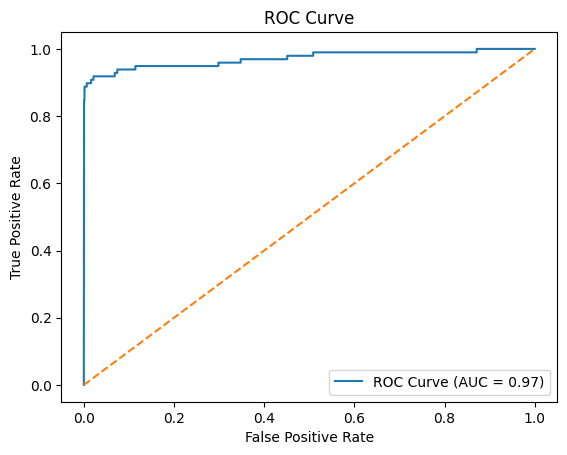

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

STEP 14: Precision-Recall Curve

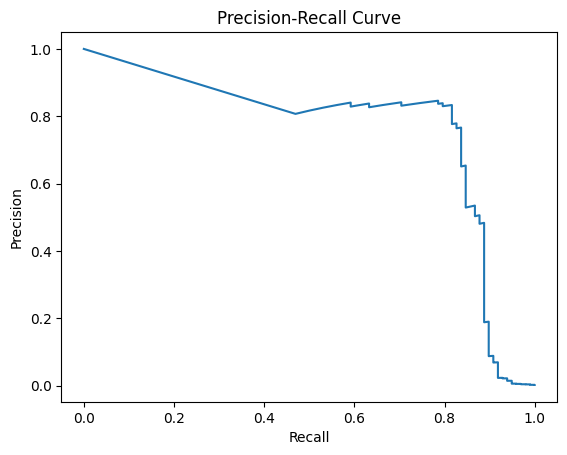

In [18]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()